Purpose: Look into results of HOMER on promoters of cis-only genes. Main goal: find motifs that are found in all genotypes, or unique to genotypes with certain CAM physiologies.<br>
Author: Anna Pardo<br>
Date initiated: Feb. 26, 2026

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [2]:
d = "/home/leviathan22/yucca-genomics/homerout/"

In [12]:
# load knownResults.txt file for each HOMER promoter set
krlist = []
for subd in os.listdir(d):
    gt = subd.split("_")[0]
    bias = subd.split("_")[1]
    df = pd.read_csv(os.path.join(d,subd,"knownResults.txt"),sep="\t",header="infer",usecols=["Motif Name","Consensus",
                                                                                             "P-value","Log P-value",
                                                                                             "q-value (Benjamini)",
                                                                                             "% of Target Sequences with Motif",
                                                                                             "% of Background Sequences with Motif"])
    #print(df.columns)
    df["genotype"] = gt
    df["subgenome_bias"] = bias
    krlist.append(df)

In [14]:
allkr = pd.concat(krlist,axis=0)
allkr.head()

,Motif Name,Consensus,P-value,Log P-value,q-value (Benjamini),% of Target Sequences with Motif,% of Background Sequences with Motif,genotype,subgenome_bias
0,REM19(REM)/colamp-REM19-DAP-Seq(GSE60143)/Homer,AAAAAAAA,1.000000e-24,-56.84,0.0,33.07%,23.25%,45,Ya
1,VRN1(ABI3VP1)/col-VRN1-DAP-Seq(GSE60143)/Homer,TTTTTTTTTT,1.000000e-21,-49.18,0.0,8.00%,3.56%,45,Ya
2,SeqBias: TA-repeat,TATATATATA,1.000000e-12,-27.67,0.0,75.53%,68.64%,45,Ya
3,Trl(Zf)/S2-GAGAfactor-ChIP-Seq(GSE40646)/Homer,RGAGAGAG,1.000000e-09,-22.23,0.0,28.45%,22.66%,45,Ya
4,bZIP18(bZIP)/colamp-bZIP18-DAP-Seq(GSE60143)/H...,KGMCAGCTND,1.000000e-09,-22.10,0.0,31.87%,25.86%,45,Ya


In [16]:
# load genotype-physiology information
phys = json.load(open("/home/leviathan22/Yucca_genomics/phys_figures/physiological_CAM_categories.json"))

In [18]:
allkr["CAMphys"] = allkr["genotype"].map(phys)

In [19]:
allkr.head()

,Motif Name,Consensus,P-value,Log P-value,q-value (Benjamini),% of Target Sequences with Motif,% of Background Sequences with Motif,genotype,subgenome_bias,CAMphys
0,REM19(REM)/colamp-REM19-DAP-Seq(GSE60143)/Homer,AAAAAAAA,1.000000e-24,-56.84,0.0,33.07%,23.25%,45,Ya,C3
1,VRN1(ABI3VP1)/col-VRN1-DAP-Seq(GSE60143)/Homer,TTTTTTTTTT,1.000000e-21,-49.18,0.0,8.00%,3.56%,45,Ya,C3
2,SeqBias: TA-repeat,TATATATATA,1.000000e-12,-27.67,0.0,75.53%,68.64%,45,Ya,C3
3,Trl(Zf)/S2-GAGAfactor-ChIP-Seq(GSE40646)/Homer,RGAGAGAG,1.000000e-09,-22.23,0.0,28.45%,22.66%,45,Ya,C3
4,bZIP18(bZIP)/colamp-bZIP18-DAP-Seq(GSE60143)/H...,KGMCAGCTND,1.000000e-09,-22.10,0.0,31.87%,25.86%,45,Ya,C3


Motif sets I want to find:
1. Those enriched across all genotypes for each bias
2. Those enriched across all genotypes (regardless of bias)
3. Those enriched across all genotypes in each physiological set (each bias)
4. Those enriched across all genotypes in each physiological set (regardless of bias)

In [24]:
# define a function to find the motif name intersection for a given genotype & bias set
def motifint(gtlist,biaslist,df=allkr):
    subdf = df[(df["genotype"].isin(gtlist)) & (df["subgenome_bias"].isin(biaslist))]
    # convert subdf to a dictionary
    outdict = {}
    for b in biaslist:
        outdict[b] = {}
        if b!="both":
            for g in gtlist:
                outdict[b][g] = set(list(subdf[(subdf["subgenome_bias"]==b) & (subdf["genotype"]==g)]["Motif Name"]))
        else:
            for g in gtlist:
                outdict[b][g] = set(list(subdf[subdf["genotype"]==g]["Motif Name"]))
    
    # find the intersection of all in each bias
    intdict = {}
    for b,gdict in outdict.items():
        intdict[b] = list(set.intersection(*list(gdict.values())))
    return intdict

In [32]:
allgt_motifs = motifint(list(allkr["genotype"].unique()),["Ya","Yf","both"],allkr[allkr["q-value (Benjamini)"]<0.05])

In [34]:
physmotifs = {}
for p in allkr["CAMphys"].unique():
    df = allkr[allkr["CAMphys"]==p]
    physmotifs[p] = motifint(list(df["genotype"].unique()),["Ya","Yf","both"],allkr[allkr["q-value (Benjamini)"]<0.05])

In [36]:
# summarize number of significantly enriched motifs in each genotype by bias overall
sigmotifs = allkr[allkr["q-value (Benjamini)"]<0.05]

In [37]:
sigmotifs.head()

,Motif Name,Consensus,P-value,Log P-value,q-value (Benjamini),% of Target Sequences with Motif,% of Background Sequences with Motif,genotype,subgenome_bias,CAMphys
0,REM19(REM)/colamp-REM19-DAP-Seq(GSE60143)/Homer,AAAAAAAA,1.000000e-24,-56.84,0.0,33.07%,23.25%,45,Ya,C3
1,VRN1(ABI3VP1)/col-VRN1-DAP-Seq(GSE60143)/Homer,TTTTTTTTTT,1.000000e-21,-49.18,0.0,8.00%,3.56%,45,Ya,C3
2,SeqBias: TA-repeat,TATATATATA,1.000000e-12,-27.67,0.0,75.53%,68.64%,45,Ya,C3
3,Trl(Zf)/S2-GAGAfactor-ChIP-Seq(GSE40646)/Homer,RGAGAGAG,1.000000e-09,-22.23,0.0,28.45%,22.66%,45,Ya,C3
4,bZIP18(bZIP)/colamp-bZIP18-DAP-Seq(GSE60143)/H...,KGMCAGCTND,1.000000e-09,-22.10,0.0,31.87%,25.86%,45,Ya,C3


In [42]:
motifcounts = sigmotifs.groupby(["genotype","subgenome_bias"]).count().reset_index()[["genotype","subgenome_bias","Motif Name"]]

In [44]:
motifcounts["CAM physiology"] = motifcounts["genotype"].map(phys)
motifcounts.sort_values(by=["CAM physiology","subgenome_bias"],ascending=True,inplace=True)
motifcounts.head()

,genotype,subgenome_bias,Motif Name,CAM physiology
0,13,Ya,190,C3
4,18,Ya,101,C3
12,36,Ya,113,C3
18,45,Ya,176,C3
30,55,Ya,127,C3


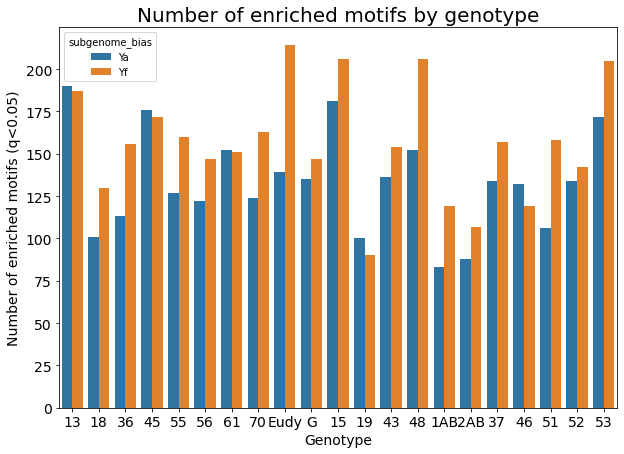

In [56]:
fig,ax = plt.subplots(figsize=(10,7))
sns.barplot(data=motifcounts,x="genotype",y="Motif Name",hue="subgenome_bias")
plt.title("Number of enriched motifs by genotype",fontsize=20)
plt.xlabel("Genotype",fontsize=14)
plt.ylabel("Number of enriched motifs (q<0.05)",fontsize=14)
ax.tick_params(which="both",labelsize=14)
plt.savefig("/home/leviathan22/yucca-genomics/homerout/motifsum_bygt.png",dpi=200,bbox_inches="tight")
plt.savefig("/home/leviathan22/yucca-genomics/homerout/motifsum_bygt.svg",dpi=200,bbox_inches="tight")
plt.savefig("/home/leviathan22/yucca-genomics/homerout/motifsum_bygt.pdf",dpi=200,bbox_inches="tight")

In [57]:
allgt_motifs

{'Ya': ['RLR1?/SacCer-Promoters/Homer',
  'VRN1(ABI3VP1)/col-VRN1-DAP-Seq(GSE60143)/Homer',
  'BMYB(HTH)/Hela-BMYB-ChIP-Seq(GSE27030)/Homer',
  'ARF16(ARF)/col-ARF16-DAP-Seq(GSE60143)/Homer',
  'SeqBias: CA-repeat',
  'MYB73(MYB)/col-MYB73-DAP-Seq(GSE60143)/Homer',
  'At3g60580(C2H2)/col-At3g60580-DAP-Seq(GSE60143)/Homer',
  'RUNX1(Runt)/Jurkat-RUNX1-ChIP-Seq(GSE29180)/Homer',
  'bZIP18(bZIP)/colamp-bZIP18-DAP-Seq(GSE60143)/Homer',
  'Tgif2(Homeobox)/mES-Tgif2-ChIP-Seq(GSE55404)/Homer',
  'SeqBias: GA-repeat',
  'TF3A(C2H2)/col-TF3A-DAP-Seq(GSE60143)/Homer',
  'HY5(bZIP)/colamp-HY5-DAP-Seq(GSE60143)/Homer',
  'Trl(Zf)/S2-GAGAfactor-ChIP-Seq(GSE40646)/Homer',
  'Tgif1(Homeobox)/mES-Tgif1-ChIP-Seq(GSE55404)/Homer',
  'GAGA-repeat/Arabidopsis-Promoters/Homer',
  'SeqBias: TA-repeat',
  'bZIP50(bZIP)/colamp-bZIP50-DAP-Seq(GSE60143)/Homer',
  'HuR(?)/HEK293-HuR-CLIP-Seq(GSE87887)/Homer',
  'SeqBias: A/T bias',
  'RUNX2(Runt)/PCa-RUNX2-ChIP-Seq(GSE33889)/Homer',
  'REM19(REM)/colamp-REM19-DA

In [58]:
# for intersections of enriched motifs: make a df with columns = motif name, genotype set, bias (1 row per motif-gtset-bias combo)
## eventually: combine data from all dicts into one df
dfdict = {"motif":[],"genotypes":[],"bias":[]}
for k,v in allgt_motifs.items():
    for i in v:
        dfdict['motif'].append(i)
        dfdict['bias'].append(k)
        dfdict['genotypes'].append("all")

In [60]:
for k,v in physmotifs.items():
    for i,j in v.items():
        for x in j:
            dfdict['motif'].append(x)
            dfdict['bias'].append(i)
            dfdict['genotypes'].append(k)

In [62]:
motif_intersects = pd.DataFrame(dfdict)

In [63]:
motif_intersects.head()

,motif,genotypes,bias
0,RLR1?/SacCer-Promoters/Homer,all,Ya
1,VRN1(ABI3VP1)/col-VRN1-DAP-Seq(GSE60143)/Homer,all,Ya
2,BMYB(HTH)/Hela-BMYB-ChIP-Seq(GSE27030)/Homer,all,Ya
3,ARF16(ARF)/col-ARF16-DAP-Seq(GSE60143)/Homer,all,Ya
4,SeqBias: CA-repeat,all,Ya


In [64]:
# plot the number of intersecting motifs in each genotype x bias set
mintcount = motif_intersects.groupby(["genotypes","bias"]).count().reset_index()
mintcount.head()

,genotypes,bias,motif
0,C3,Ya,50
1,C3,Yf,51
2,C3,both,85
3,all,Ya,26
4,all,Yf,23


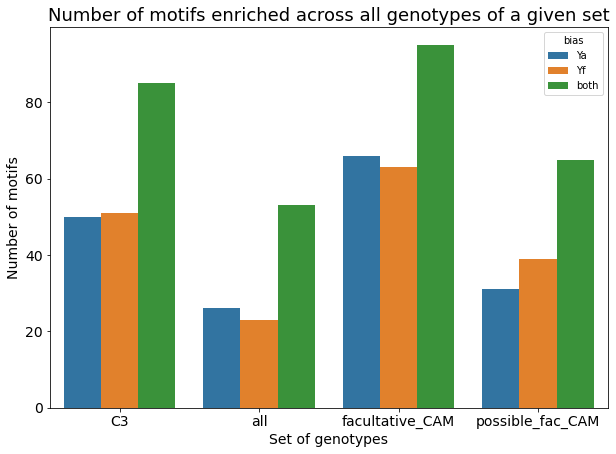

In [70]:
fig,ax = plt.subplots(figsize=(10,7))
sns.barplot(data=mintcount,x="genotypes",y="motif",hue="bias")
plt.title("Number of motifs enriched across all genotypes of a given set",fontsize=18)
plt.ylabel("Number of motifs",fontsize=14)
plt.xlabel("Set of genotypes",fontsize=14)
ax.tick_params(which="both",labelsize=14)
plt.savefig("/home/leviathan22/yucca-genomics/homerout/summary_motif_intersections.png",dpi=200,bbox_inches="tight")
plt.savefig("/home/leviathan22/yucca-genomics/homerout/summary_motif_intersections.svg",dpi=200,bbox_inches="tight")
plt.savefig("/home/leviathan22/yucca-genomics/homerout/summary_motif_intersections.pdf",dpi=200,bbox_inches="tight")

Next operation: For each bias set (Ya, Yf, and both), find the motifs enriched in all genotypes of each physiology (C3, fac CAM, & possible fac CAM) that are NOT enriched in ANY genotype of the other two sets. (i.e. motifs that are uniquely enriched in all genotypes of a given physiological category - particular interest in facultative CAM here)

In [71]:
sigmotifs.head()

,Motif Name,Consensus,P-value,Log P-value,q-value (Benjamini),% of Target Sequences with Motif,% of Background Sequences with Motif,genotype,subgenome_bias,CAMphys
0,REM19(REM)/colamp-REM19-DAP-Seq(GSE60143)/Homer,AAAAAAAA,1.000000e-24,-56.84,0.0,33.07%,23.25%,45,Ya,C3
1,VRN1(ABI3VP1)/col-VRN1-DAP-Seq(GSE60143)/Homer,TTTTTTTTTT,1.000000e-21,-49.18,0.0,8.00%,3.56%,45,Ya,C3
2,SeqBias: TA-repeat,TATATATATA,1.000000e-12,-27.67,0.0,75.53%,68.64%,45,Ya,C3
3,Trl(Zf)/S2-GAGAfactor-ChIP-Seq(GSE40646)/Homer,RGAGAGAG,1.000000e-09,-22.23,0.0,28.45%,22.66%,45,Ya,C3
4,bZIP18(bZIP)/colamp-bZIP18-DAP-Seq(GSE60143)/H...,KGMCAGCTND,1.000000e-09,-22.10,0.0,31.87%,25.86%,45,Ya,C3


In [79]:
# define a function to do this for a given physiological set
def find_physuniq_motifs(physcat,dic=physmotifs,df=sigmotifs):
    # set up the input data
    notphys = df[df["CAMphys"]!=physcat]
    dsub = dic[physcat]
    
    outdict = {}
    for k,v in dsub.items():
        bdf = notphys[notphys["subgenome_bias"]==k]
        umotifs = list(set(v).difference(set(list(bdf["Motif Name"]))))
        outdict[k] = umotifs
    return outdict

In [80]:
phys_unique_motifs = {}
for k in physmotifs.keys():
    phys_unique_motifs[k] = find_physuniq_motifs(k)

In [77]:
phys_unique_motifs

{'C3': {'Ya': set(),
  'Yf': set(),
  'both': {'ABF2(bZIP)/col-ABF2-DAP-Seq(GSE60143)/Homer',
   'ANL2(HB)/col-ANL2-DAP-Seq(GSE60143)/Homer',
   'AREB3(bZIP)/col-AREB3-DAP-Seq(GSE60143)/Homer',
   'ARF16(ARF)/col-ARF16-DAP-Seq(GSE60143)/Homer',
   'AT3G12130(C3H)/colamp-AT3G12130-DAP-Seq(GSE60143)/Homer',
   'AT5G47660(Trihelix)/colamp-AT5G47660-DAP-Seq(GSE60143)/Homer',
   'ATHB20(Homeobox)/colamp-ATHB20-DAP-Seq(GSE60143)/Homer',
   'ATHB23(ZFHD)/col-ATHB23-DAP-Seq(GSE60143)/Homer',
   'ATHB24(ZFHD)/colamp-ATHB24-DAP-Seq(GSE60143)/Homer',
   'ATHB25(ZFHD)/colamp-ATHB25-DAP-Seq(GSE60143)/Homer',
   'ATHB33(ZFHD)/col-ATHB33-DAP-Seq(GSE60143)/Homer',
   'ATHB34(ZFHD)/colamp-ATHB34-DAP-Seq(GSE60143)/Homer',
   'ATY13(MYB)/col-ATY13-DAP-Seq(GSE60143)/Homer',
   'At1g64620(C2C2dof)/colamp-At1g64620-DAP-Seq(GSE60143)/Homer',
   'At1g77640(AP2EREBP)/col-At1g77640-DAP-Seq(GSE60143)/Homer',
   'At2g45680(TCP)/colamp-At2g45680-DAP-Seq(GSE60143)/Homer',
   'At3g60580(C2H2)/col-At3g60580-DAP-Seq(G

In [81]:
with open("/home/leviathan22/yucca-genomics/homerout/phys_unique_motifs.json","w+") as outfile:
    json.dump(phys_unique_motifs,outfile)

In [82]:
sigmotifs.head()

,Motif Name,Consensus,P-value,Log P-value,q-value (Benjamini),% of Target Sequences with Motif,% of Background Sequences with Motif,genotype,subgenome_bias,CAMphys
0,REM19(REM)/colamp-REM19-DAP-Seq(GSE60143)/Homer,AAAAAAAA,1.000000e-24,-56.84,0.0,33.07%,23.25%,45,Ya,C3
1,VRN1(ABI3VP1)/col-VRN1-DAP-Seq(GSE60143)/Homer,TTTTTTTTTT,1.000000e-21,-49.18,0.0,8.00%,3.56%,45,Ya,C3
2,SeqBias: TA-repeat,TATATATATA,1.000000e-12,-27.67,0.0,75.53%,68.64%,45,Ya,C3
3,Trl(Zf)/S2-GAGAfactor-ChIP-Seq(GSE40646)/Homer,RGAGAGAG,1.000000e-09,-22.23,0.0,28.45%,22.66%,45,Ya,C3
4,bZIP18(bZIP)/colamp-bZIP18-DAP-Seq(GSE60143)/H...,KGMCAGCTND,1.000000e-09,-22.10,0.0,31.87%,25.86%,45,Ya,C3


In [86]:
# find unique motifs for each genotype as well
def findunique_gt(gt,bias="both",df=sigmotifs):
    if bias=="both":
        gtmotifs = set(list(df[df["genotype"]==gt]["Motif Name"]))
        notgtmotifs = set(list(df[df["genotype"]!=gt]["Motif Name"]))
    else:
        gtmotifs = set(list(df[(df["genotype"]==gt) & (df["subgenome_bias"]==bias)]["Motif Name"]))
        notgtmotifs = set(list(df[(df["genotype"]!=gt) & (df["subgenome_bias"]==bias)]["Motif Name"]))
        
    return list(gtmotifs.difference(notgtmotifs))

In [90]:
unique_gt_motifs = {}
for g in sigmotifs["genotype"].unique():
    unique_gt_motifs[g] = {}
    for b in ["Ya","Yf","both"]:
        unique_gt_motifs[g][b] = findunique_gt(g,b)